# here the goal is show the cluste quality over varying size of clusters
- data is 10-d
- comare three mehtods: GMM on PCA space, GMM on scvi space and mmidas results

In [1]:
%load_ext autoreload
%autoreload 2
import sys, os
notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))
from notebooks.config import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scvi
import pickle as pkl
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from functools import partial

# Figure saving setup
SAVE_FIGURES = False
fig_path = SNRNA_FIGURE_DIR
save_figure = partial(save_figure, dir_path=fig_path)

PROJECT_ROOT: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics
CODE_DIR: /allen/aind/scratch/shuonan.chen/code/LCNE_transcriptomics/code
CODE_DIR exists: True
Python path includes CODE_DIR: True


# laod data

In [2]:
myfilename = os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad")
adata_sc = sc.read_h5ad(myfilename)

# Prepare data matrices
data = {
    'gene_id': adata_sc.var_names,
    'BN_raw': adata_sc.layers['BN'],
    'log1p': np.log1p(adata_sc.layers['BN'] * 1e+6)
}

# Parameters
num_components = 10
K_range = range(1, 16)
random_seeds = [1, 2, 3, 4, 5]
n_seeds = len(random_seeds)

## some functions

In [3]:
def run_gmm_analysis(data_matrix, space_name, random_seeds, K_range):
    """Run GMM clustering analysis across multiple seeds and K values"""
    all_scores = []
    print(f"Running GMM clustering on {space_name} space...")
    
    for seed_idx, seed in enumerate(random_seeds):
        print(f"Seed {seed} ({seed_idx+1}/{len(random_seeds)})")
        silhouette_K = {}
        
        for K in K_range:
            if K == 1:
                silhouette_K[K] = 1.0
            else:
                gmm = GaussianMixture(n_components=K, random_state=seed,
                                    covariance_type='full', max_iter=1000, n_init=10)
                cluster_labels = gmm.fit_predict(data_matrix)
                silhouette_K[K] = silhouette_score(data_matrix, cluster_labels)
                
        all_scores.append(silhouette_K)
    
    # Convert to array format
    n_categories = len(K_range)
    scores_array = np.full((len(random_seeds), n_categories), np.nan)
    for seed_idx, seed_results in enumerate(all_scores):
        for k_idx, K in enumerate(K_range):
            if K in seed_results:
                scores_array[seed_idx, k_idx] = seed_results[K]
    
    return scores_array

# 1. GMM on PCA space

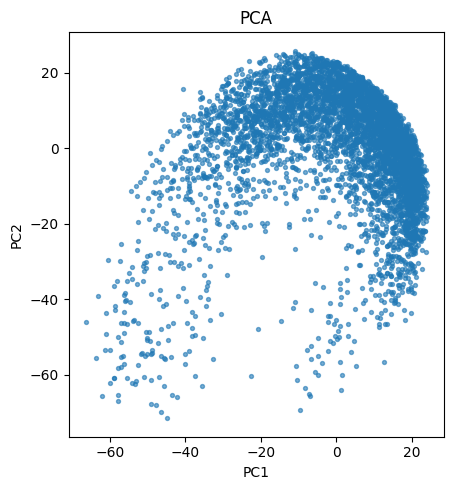

In [4]:
scaler = StandardScaler(with_mean=True, with_std=True)
Xtr = scaler.fit_transform(data['log1p'])
pca = PCA(n_components=num_components, random_state=0)
Ztr_pca = pca.fit_transform(Xtr)

plt.figure(figsize=(5,5))
plt.scatter(Ztr_pca[:,0], Ztr_pca[:,1], s=8, alpha=0.6)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA')
plt.gca().set_aspect('equal')
plt.tight_layout(); plt.show()


In [ ]:
gmm_pca_scores = run_gmm_analysis(Ztr_pca, "PCA", random_seeds, K_range)
mean_pca = np.nanmean(gmm_pca_scores, axis=0)
std_pca = np.nanstd(gmm_pca_scores, axis=0)

Running GMM clustering on PCA space...
Seed 1 (1/5)
Seed 2 (2/5)


# 2. GMM on scvi 

In [ ]:
scvi.settings.seed = 1
scvi.model.SCVI.setup_anndata(adata_sc, batch_key='sex')
model = scvi.model.SCVI(adata_sc, n_layers=1, n_latent=num_components, gene_likelihood="zinb")
model.train()

adata_sc.obsm['X_scVI'] = model.get_latent_representation()
Ztr_scvi = adata_sc.obsm['X_scVI']

gmm_scvi_scores = run_gmm_analysis(Ztr_scvi, "scVI", random_seeds, K_range)
mean_scvi = np.nanmean(gmm_scvi_scores, axis=0)
std_scvi = np.nanstd(gmm_scvi_scores, axis=0)

# 3. MMIDAS
- for this part we should prob just save the results somewhere 

In [ ]:
mmidas_res_path = "/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/data/snRNA/all_mmidas_outcome_11.pkl"
all_results = pkl.load(open(mmidas_res_path, 'rb'))

def process_mmidas_results(all_results, eval_space, space_name):
    """Process MMIDAS results for a given evaluation space"""
    n_seeds = len(np.unique([r['seed_i'] for r in all_results]))
    num_K = len(np.unique([r['outcome']['num_pruned'][0] for r in all_results]))   
    scores = np.empty((n_seeds, num_K, 2))  # [seeds, K, arms]
    for result in all_results:
        outcome = result['outcome']
        K = outcome['num_pruned'][0]
        seed_i = result['seed_i']
        if K == 1:
            arm_scores = [1.0, 1.0]
        else:
            arm_scores = []
            for arm_id in [0, 1]:
                predicted_labels = outcome['pred_label'][0][arm_id].flatten()
                score = silhouette_score(eval_space, predicted_labels)
                arm_scores.append(score)
        scores[seed_i, K-1] = arm_scores
    mean_arm0 = np.nanmean(scores[..., 0], axis=0)
    mean_arm1 = np.nanmean(scores[..., 1], axis=0)
    overall_mean = (mean_arm0 + mean_arm1) / 2
    std_arm0 = np.nanstd(scores[..., 0], axis=0)
    std_arm1 = np.nanstd(scores[..., 1], axis=0)
    overall_std = np.sqrt((std_arm0**2 + std_arm1**2) / 2)
    return overall_mean, overall_std


mmidas_pca_mean, mmidas_pca_std = process_mmidas_results(all_results, Ztr_pca, "PCA")
mmidas_scvi_mean, mmidas_scvi_std = process_mmidas_results(all_results, Ztr_scvi, "scVI")

In [ ]:
x_pos = np.arange(len(K_range))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# PCA space comparison
ax1.errorbar(x_pos, mean_pca, yerr=std_pca, marker='o', 
             label='GMM on PCA', linewidth=2, capsize=3)
ax1.errorbar(x_pos, mmidas_pca_mean, yerr=mmidas_pca_std, marker='^', 
             label='MMIDAS (eval on PCA)', linewidth=2, capsize=3)
ax1.set_xlabel('Number of Categories (K)')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('PCA Space Comparison')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(K_range)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# scVI space comparison
ax2.errorbar(x_pos, mean_scvi, yerr=std_scvi, marker='s', 
             label='GMM on scVI', linewidth=2, capsize=3)
ax2.errorbar(x_pos, mmidas_scvi_mean, yerr=mmidas_scvi_std, marker='^', 
             label='MMIDAS (eval on scVI)', linewidth=2, capsize=3)
ax2.set_xlabel('Number of Categories (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('scVI Space Comparison')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(K_range)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# try to get the results from the saved pickl 

In [ ]:
def generate_simulated_data(Ztr_pca, adata_sc, n1=100, n2=100, frac_tail=0.1, seed=0):
    """Generate simulated data based on arc endpoints"""
    # Load pseudocluster scores
    arc_path = TMP_OUT_DIR + '/cellID_pc_0722.csv'
    arcinfo = pd.read_csv(arc_path).set_index('cellID')
    scores_01 = arcinfo['pseudoclusters'].reindex(adata_sc.obs.index).values
    
    # Get endpoints
    rng = np.random.default_rng(seed)
    low_idx = np.where(scores_01 < frac_tail)[0]
    high_idx = np.where(scores_01 >= 1 - frac_tail)[0]
    
    Z_low = Ztr_pca[low_idx]
    Z_high = Ztr_pca[high_idx]
    
    # Fit Gaussians
    mu_low, mu_high = Z_low.mean(axis=0), Z_high.mean(axis=0)
    cov_low = np.diag(Z_low.var(axis=0, ddof=1))
    cov_high = np.diag(Z_high.var(axis=0, ddof=1))
    
    # Generate synthetic data
    Z_syn_low = rng.multivariate_normal(mu_low, cov_low, size=n1)
    Z_syn_high = rng.multivariate_normal(mu_high, cov_high, size=n2)
    Z_syn = np.vstack([Z_syn_low, Z_syn_high])
    return Z_syn, Z_low, Z_high

Z_syn, Z_low, Z_high = generate_simulated_data(Ztr_pca, adata_sc)

plt.figure(figsize=(5,5))
plt.scatter(Ztr_pca[:,0], Ztr_pca[:,1], s=1, alpha=0.2, label='Original data', color='gray')
plt.scatter(Z_low[:,0], Z_low[:,1], s=8, alpha=0.5, label='group1')
plt.scatter(Z_high[:,0], Z_high[:,1], s=8, alpha=0.5, label='group2')
plt.scatter(Z_syn[:,0], Z_syn[:,1], s=0.6, alpha=1, label='Simulated')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Real vs Simulated Data')
plt.gca().set_aspect('equal'); plt.legend(); plt.show()

In [ ]:
sim_scores = run_gmm_analysis(Z_syn, "Simulated", random_seeds, K_range)
mean_sim = np.nanmean(sim_scores, axis=0)
std_sim = np.nanstd(sim_scores, axis=0)

# Create final comparison plot
plt.figure(figsize=(6, 4))
plt.errorbar(x_pos, mean_sim, yerr=std_sim, marker='o', 
             label='Simulated data', linewidth=2, capsize=3)
plt.errorbar(x_pos, mean_pca, yerr=std_pca, marker='s', 
             label='GMM on PCA (real)', linewidth=2, capsize=3)
plt.errorbar(x_pos, mmidas_pca_mean, yerr=mmidas_pca_std, marker='^', 
             label='MMIDAS (eval on PCA)', linewidth=2, capsize=3)

plt.xlabel('Number of Categories (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Clustering Quality Comparison: Simulated vs Real Data', fontsize=14)
plt.xticks(x_pos, K_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
